In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [37]:
np.random.seed(33550336)
rng = np.random.default_rng()

In [3]:
blob1 = np.random.normal(2, 0.5, (50, 2))
blob2 = np.random.normal(4, 0.5, (50, 2))
y = np.ones(100)
y[50:] = -1
x = np.vstack((blob1, blob2))

In [4]:
np.unique(y)

array([-1.,  1.])

In [5]:
P = np.ones((100, 100))
for i in range(100):
    for j in range(100):
        P[i][j] = y[i] * y[j] * x[i].T @ x[j] 

In [6]:
np.allclose(P, P.T)

True

In [7]:
np.linalg.eigvalsh(P)

array([-1.65184937e-13, -3.67962813e-14, -3.48232225e-14, -3.16489985e-14,
       -2.95752757e-14, -2.81100185e-14, -2.53470421e-14, -2.42790120e-14,
       -2.32460419e-14, -2.16410342e-14, -2.05122028e-14, -1.91400050e-14,
       -1.79491319e-14, -1.76758486e-14, -1.66287257e-14, -1.58021007e-14,
       -1.45214804e-14, -1.36197195e-14, -1.27214640e-14, -1.15043278e-14,
       -1.10473703e-14, -1.05216701e-14, -9.78210549e-15, -9.00532212e-15,
       -8.82122790e-15, -8.12694872e-15, -7.77297786e-15, -7.39819440e-15,
       -6.58006088e-15, -6.14882361e-15, -5.87017278e-15, -5.36529195e-15,
       -5.15464479e-15, -4.71958762e-15, -4.27331098e-15, -4.02651299e-15,
       -3.90526146e-15, -3.39598040e-15, -3.02726288e-15, -2.78897149e-15,
       -2.53175566e-15, -2.41319892e-15, -1.68184799e-15, -1.44297864e-15,
       -1.26575197e-15, -9.28163980e-16, -8.21107101e-16, -5.12031460e-16,
       -2.66472600e-16, -7.83886340e-17,  2.10659024e-16,  5.30093978e-16,
        9.21946770e-16,  

In [8]:
for i in range(100):
    if(P[i][i] < 0):
        print("boo")

In [9]:
def obj(alpha):
    return 0.5 * (alpha.T @ P @ alpha) - (np.ones(len(alpha)) @ alpha)

In [10]:
def grad(alpha):
    return P @ alpha - np.ones(len(alpha))

In [11]:
alph = np.zeros(100)

In [12]:
bounds = [(0, None)] * len(alph)

In [13]:
def eqcon(alpha):
    return np.sum(alpha @ y)

In [14]:
cons = {'type' : 'eq','fun' : eqcon}

In [15]:
res = sp.optimize.minimize(obj, alph, method = 'SLSQP', jac = grad, bounds = bounds, constraints = cons)

In [17]:
w = (res.x * y) @ x

In [18]:
w

array([-1.49185084, -2.22516246])

In [19]:
sv = np.where(res.x > 1e-5)[0]

In [20]:
sv

array([12, 50, 76])

In [22]:
b = np.mean([y[i] - w @ x[i] for i in sv])

In [23]:
b

np.float64(11.085339623758586)

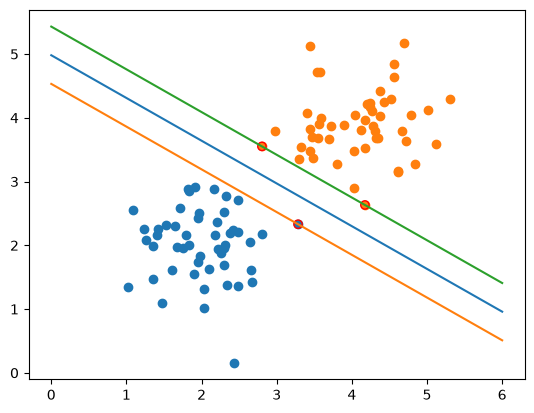

In [30]:
x1, x2 = x.T
plt.scatter(x1[:50], x2[:50])
plt.scatter(x1[50:], x2[50:])
xs = np.linspace(0, 6, 100)
plt.plot(xs, (0 - b - w[0]*xs) / w[1])   
plt.plot(xs, (1 - b - w[0]*xs) / w[1])   
plt.plot(xs, (-1 - b - w[0]*xs) / w[1])  
plt.scatter(x[sv, 0], x[sv, 1], facecolors = 'none', edgecolors = 'r')

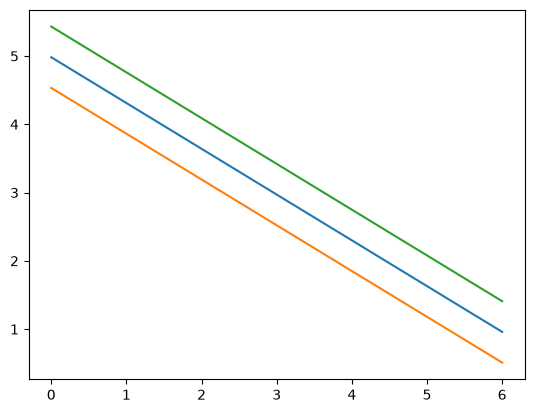

In [28]:
xs = np.linspace(0, 6, 100)
plt.plot(xs, (0 - b - w[0]*xs) / w[1])   # boundary
plt.plot(xs, (1 - b - w[0]*xs) / w[1])   # margin +
plt.plot(xs, (-1 - b - w[0]*xs) / w[1])  # margin -

In [34]:
from sklearn.datasets import make_moons

In [39]:
X, y = make_moons(n_samples = 200, noise = 0.3, random_state = 33550336)

In [44]:
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]
xtr, xv, xte = X[:120], X[120:160], X[160:]
ytr, yv, yte = y[:120], y[120:160], y[160:]
mu = xtr.mean(axis=0)
sd = xtr.std(axis=0)
X_train = (xtr - mu) / sd
X_val = (xv - mu) / sd
X_test = (xte - mu) / sd

In [45]:
from sklearn.svm import SVC

In [49]:
gamas = [0.1, 1, 10]
modles = []
for g in gamas:
    modle = SVC(kernel = 'rbf', C = 1, gamma = g)
    modle.fit(X_train, ytr)
    modles.append(modle)

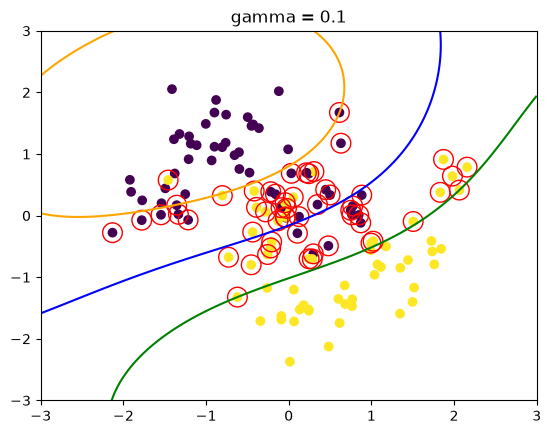

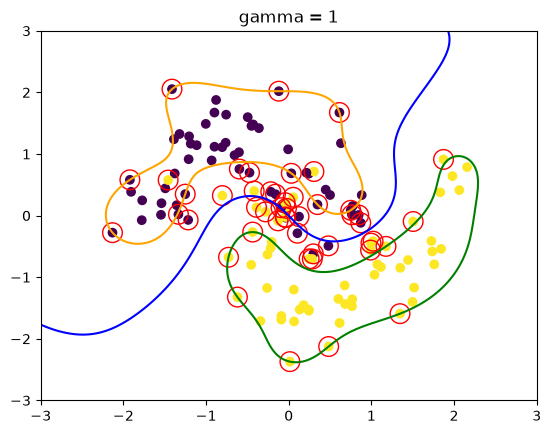

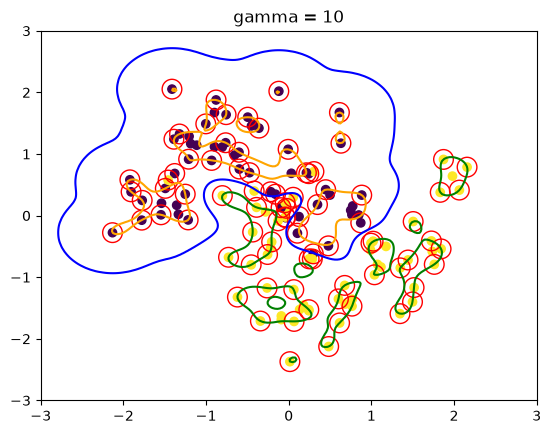

In [52]:
for i, mode in enumerate(modles):
    Z = mode.decision_function(mesh).reshape(xx.shape)
    plt.figure()
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['orange', 'blue', 'green'])
    plt.scatter(X_train[:, 0], X_train[:, 1], c=ytr)
    plt.scatter(mode.support_vectors_[:, 0], mode.support_vectors_[:, 1], 
                s=200, facecolors='none', edgecolors='r')
    plt.title(f'gamma = {gamas[i]}')